In [1]:
import duckdb
import matplotlib.pyplot as plt

In [2]:
con = duckdb.connect(':memory:')

In [3]:
con.sql("""CREATE OR REPLACE VIEW data AS
SELECT 
    \"VAL:UINT64:NOT_NULLABLE\" AS VAL,
    \"TS:UINT64:IS_NULLABLE\" AS ts,
    EPOCH_MS(\"emittedtime:UINT64:NOT_NULLABLE\") AS et
FROM 'data/out.csv'""")

In [9]:
data = con.sql("""
    SELECT date_diff('second', et, (SELECT MIN(et) FROM data)) AS time,
           COUNT(*) AS count
    FROM data
    GROUP BY time
    ORDER BY time;
""").fetchnumpy()

In [10]:
data

{'time': array([-3000, -2999, -2998, ...,    -2,    -1,     0], shape=(3001,)),
 'count': array([1170, 3920, 3930, ..., 3930, 3930, 2756], shape=(3001,))}

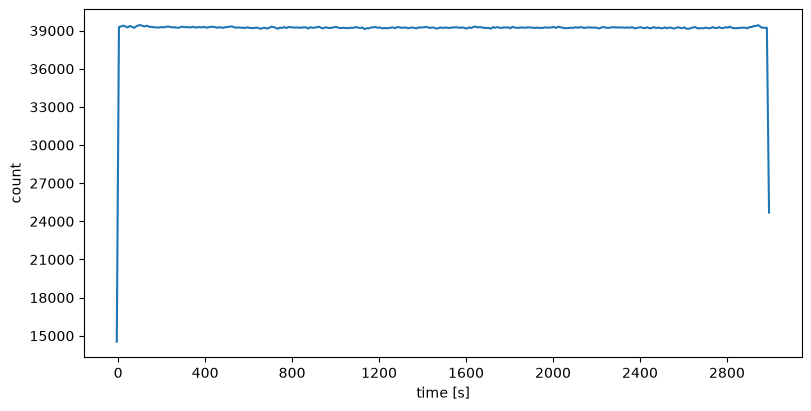

In [6]:
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots(figsize=(8, 4), layout='constrained')
ax.plot(data['time'], data['count'])
ax.set_xlabel('time [s]')
ax.set_ylabel('count')
ax.ticklabel_format(style='plain', useOffset=False)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()